# 2.5d — Dérive de distribution au déploiement : détecter, corriger, savoir quand on ne peut pas

L'arc d'évaluation du cours (2.5 biais-variance et validation croisée, 2.5b calibration, 2.5c équité) repose tous sur une hypothèse silencieuse : **l'échantillon de validation est tiré de la même distribution que les données d'entraînement**. Ce carnet lève cette hypothèse — la quatrième axe d'évaluation : que se passe-t-il quand le monde du déploiement diffère de celui de l'entraînement ?

**Plan** : trois dérives construites volontairement sur un même jeu de données (covariable, étiquette, concept), chacune mesurée par l'écart entre ce que la validation croisée annonce et ce que le déploiement produit ; trois détecteurs (test à deux échantillons, classifieur discriminant, MMD) réimplémentés puis confrontés à la bibliothèque de référence `alibi-detect` ; deux corrections (pondération par importance, BBSE) et une limite honnête (la dérive de concept ne se corrige pas sans nouvelles étiquettes).

**Prérequis** : 2.5 (validation croisée), 2.12 (déséquilibre), 2.13 (analyse d'erreurs).


**Navigation** : [Série 2.5 — Biais-Variance-CV-ROC](2.5-Biais-Variance-CV-ROC.ipynb) · [2.5b Calibration](2.5b-Calibration-Probabilites.ipynb) · [2.5c Équité sous-groupes](2.5c-Equite-Sous-Groupes.ipynb) | [Index](README.md)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, brier_score_loss
from scipy import stats
from scipy.stats import multivariate_normal

RNG = np.random.default_rng(42)
plt.rcParams['figure.dpi'] = 110


***
## 1. Le setup : un modèle fidèle à son monde d'entraînement

Un classifieur logistique sur un problème synthétique à deux caractéristiques : le monde d'entraînement `W_train` (covariables `x ~ N(mu_train, I)`, règle d'étiquette linéaire bruitée). La validation croisée y est le miroir de ce monde : elle ne peut pas voir ce qui n'y est pas.


In [2]:
def echantillon_monde(n, rng, mu=np.zeros(2), w=np.array([1.0, 1.0]), delta=1.0, p1=0.5):
    """Tire (x, y) d'un monde parametre.

    y ~ Bernoulli(p1) ; x | y ~ N(mu + (2y-1) * delta * w, I).
    La regle P(y|x) est donc logistique, de direction w, centree sur mu.
    Cas particulier precieux : w -> -w inverse la regle en laissant P(x)
    EXACTEMENT inchange (les centres de classes s'echangent) -- derive de concept pure.
    """
    y = (rng.random(n) < p1).astype(int)
    centres = mu + (2 * y[:, None] - 1) * delta * w[None, :]
    x = centres + rng.standard_normal((n, 2))
    return x, y

MU_TRAIN = np.zeros(2)
W_TRAIN = np.array([1.0, 1.0])
DELTA = 1.0

X_tr, y_tr = echantillon_monde(2000, RNG, mu=MU_TRAIN, w=W_TRAIN, delta=DELTA, p1=0.5)
modele = LogisticRegression().fit(X_tr, y_tr)
cv_annonce = cross_val_score(LogisticRegression(), X_tr, y_tr, cv=5).mean()
print(f"CV 5-fold sur W_train : accuracy = {cv_annonce:.3f}")
print(f"Frontiere apprise : w = {modele.coef_[0].round(3)}, b = {modele.intercept_[0]:+.3f}")
print(f"(verite du monde   : direction w = {W_TRAIN}, homothetie delta = {DELTA})")


CV 5-fold sur W_train : accuracy = 0.919
Frontiere apprise : w = [1.892 1.981], b = -0.031
(verite du monde   : direction w = [1. 1.], homothetie delta = 1.0)


***
## 2. Trois dérives, trois mondes de déploiement

| Dérive | Ce qui change | Ce qui reste | Se corrige ? |
|---|---|---|---|---|
| **Covariable (covariate shift)** | `P(x)` | `P(y|x)` | oui, par pondération d'importance |
| **Étiquette (label shift)** | `P(y)` | `P(x|y)` | oui, par BBSE |
| **Concept (concept drift)** | `P(y|x)` | `P(x)` | **non, sans nouvelles étiquettes** |

Chaque monde de déploiement `W_dep_k` est construit à partir du même générateur, une seule composante modifiée à la fois. Pour chaque dérive : ce que la CV annonce (score en validation sur `W_train`) contre ce que le déploiement produit (score sur `W_dep_k`).


In [3]:
# Les trois mondes de deploiement -- une seule composante change a la fois.
X_dep_cov, y_dep_cov = echantillon_monde(1000, RNG, mu=MU_TRAIN + np.array([2.5, 0.0]), w=W_TRAIN, delta=DELTA, p1=0.5)
X_dep_lab, y_dep_lab = echantillon_monde(1000, RNG, mu=MU_TRAIN, w=W_TRAIN, delta=DELTA, p1=0.85)
X_dep_con, y_dep_con = echantillon_monde(1000, RNG, mu=MU_TRAIN, w=-W_TRAIN, delta=DELTA, p1=0.5)

lignes = []
for nom, Xd, yd in [("covariable", X_dep_cov, y_dep_cov),
                     ("etiquette", X_dep_lab, y_dep_lab),
                     ("concept", X_dep_con, y_dep_con)]:
    produit = accuracy_score(yd, modele.predict(Xd))
    lignes.append({"derive": nom,
                   "ce que la CV annonce": round(cv_annonce, 3),
                   "ce que le deploiement produit": round(produit, 3),
                   "ecart": round(cv_annonce - produit, 3)})
ecarts = pd.DataFrame(lignes).set_index("derive")
ecarts


,ce que la CV annonce,ce que le deploiement produit,ecart
derive,,,
covariable,0.919,0.692,0.227
etiquette,0.919,0.918,0.001
concept,0.919,0.068,0.850


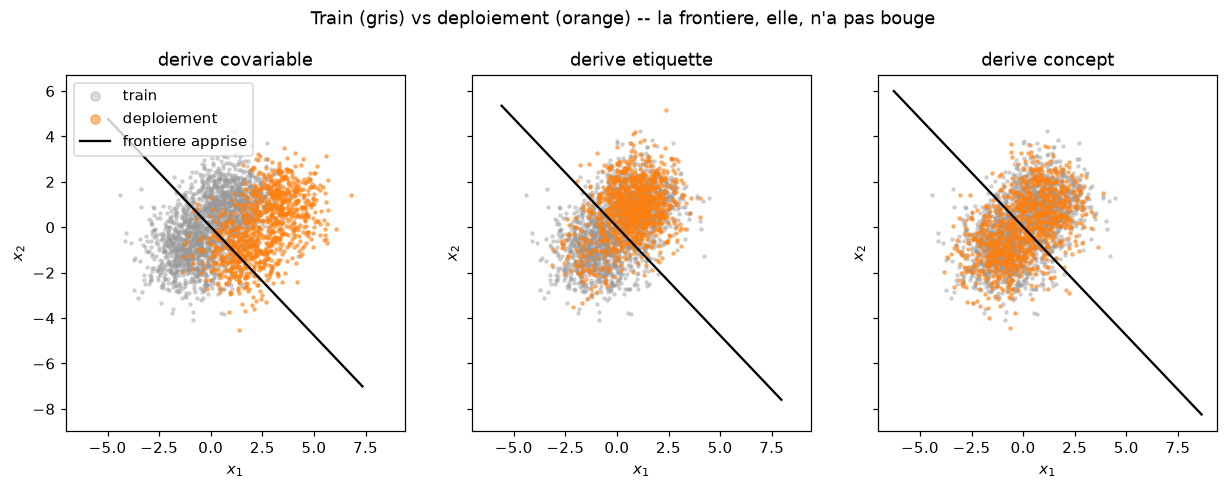

In [4]:
def frontiere(ax, modele, xlim, ylim, couleur="k"):
    """Trace la frontiere apprise (w.x + b = 0)."""
    a, b = modele.coef_[0]
    c = modele.intercept_[0]
    xs = np.linspace(*xlim, 50)
    ax.plot(xs, -(a * xs + c) / b, couleur, lw=1.5, label="frontiere apprise")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharex=True, sharey=True)
for ax, (nom, Xd) in zip(axes, [("covariable", X_dep_cov), ("etiquette", X_dep_lab), ("concept", X_dep_con)]):
    ax.scatter(*X_tr.T, s=4, c="0.6", alpha=0.35, label="train")
    ax.scatter(*Xd.T, s=4, c="tab:orange", alpha=0.5, label="deploiement")
    frontiere(ax, modele, ax.get_xlim(), ax.get_ylim())
    ax.set_title(f"derive {nom}")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
axes[0].legend(markerscale=3, loc="upper left")
fig.suptitle("Train (gris) vs deploiement (orange) -- la frontiere, elle, n'a pas bouge", y=1.02)
plt.show()


**Lecture** — les trois échantillons de déploiement (orange) contre l'entraînement (gris) :

- **covariable** : le nuage orange a glissé vers `x1 > 0` — la frontière traverse maintenant une zone que le modèle n'a jamais vue en entraînement. `P(y|x)` est identique (même règle, même bruit), mais le modèle est interrogé hors de son terrain.
- **étiquette** : le nuange orange s'est densifié du côté `y=1` (85 % de la masse contre 50 % au entraînement). Chaque classe garde la même loi conditionnelle `P(x|y)`.
- **concept** : le nuage orange recouvre *exactement* le gris (même `P(x)`) — c'est la **règle d'étiquetage qui s'est inversée** (`w → −w` : les centres de classes ont échangé leurs places, la marginale est identique au signe près). Rien ne se voit sur cette figure : c'est le point de la section 3.

L'écart annonce/produit est la **première** mesure à prendre avant toute correction : il quantifie le problème que les sections suivantes apprendront à détecter puis, parfois, à corriger.


***
## 3. Détecter : trois détecteurs, réimplémentés puis confrontés à la référence

1. **Test à deux échantillons** (Kolmogorov-Smirnov par caractéristique, agrégation Bonferroni) — `scipy.stats.ks_2samp`, puis `alibi_detect.cd.KSDrift`.
2. **Classifieur discriminant** — un classifieur entraîné à distinguer entraînement/déploiement ; son AUC près de 0,5 = pas de dérive, près de 1,0 = dérive détectée (et ses coefficients disent *où*).
3. **MMD (maximum mean discrepancy)** — noyau gaussien, estimation non biaisée, test par permutation.

Chaque détecteur est d'abord écrit en quelques lignes lisibles, puis confronté à `alibi-detect` (la bibliothèque de référence du domaine) sur les mêmes échantillons : le verdict SOTA se lit dans la comparaison, pas dans la réimplémentation seule.

> **Référence.** Gretton, Borgwardt, Rasch, Schölkopf & Smola (2012), *A Kernel Two-Sample Test* — le MMD comme différence de moyennes en espace à noyau, estimateur non biaisé et test par permutation. Rabanser, Günlük & Wu (2019), *Failing Loudly: An Empirical Study of Methods for Detecting Dataset Shift* — le classifieur discriminant comme détecteur de dérive, et la hiérarchie de ce que chaque famille voit ou rate.


In [5]:
## Detecteur 1 : KS par caracteristique, reimplemente
def ks_par_variable(X_ref, X_new):
    """KS univarie par feature + agragation Bonferroni (la regle par defaut d'alibi-detect)."""
    pvals = np.array([stats.ks_2samp(X_ref[:, j], X_new[:, j]).pvalue
                      for j in range(X_ref.shape[1])])
    return pvals, min(1.0, len(pvals) * pvals.min())

mondes = {"covariable": X_dep_cov, "etiquette": X_dep_lab, "concept": X_dep_con}
for nom, Xd in mondes.items():
    pvals, p_bonf = ks_par_variable(X_tr, Xd)
    verdict = "DERIVE" if p_bonf < 0.05 else "rien vu"
    print(f"{nom:11s}  p par variable = {np.array2string(pvals, precision=3)}  p Bonferroni = {p_bonf:.2e}  -> {verdict}")


covariable   p par variable = [1.139e-224 4.591e-001]  p Bonferroni = 2.28e-224  -> DERIVE
etiquette    p par variable = [1.889e-32 1.258e-31]  p Bonferroni = 3.78e-32  -> DERIVE
concept      p par variable = [0.993 0.459]  p Bonferroni = 9.18e-01  -> rien vu


In [6]:
## Le meme test, par la bibliotheque de reference : alibi-detect (KS : scipy, sans reseau)
from alibi_detect.cd import KSDrift

cd_ks = KSDrift(X_tr, p_val=0.05)
for nom, Xd in mondes.items():
    pred = cd_ks.predict(Xd)['data']
    print(f"{nom:11s}  is_drift = {pred['is_drift']}  "
          f"p min = {pred['p_val'].min():.2e}  seuil = {pred['threshold']:.3f}")


<USER_PATH>\.conda\envs\coursia-drift\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
<USER_PATH>\.conda\envs\coursia-drift\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


covariable   is_drift = 1  p min = 0.00e+00  seuil = 0.025
etiquette    is_drift = 1  p min = 1.33e-32  seuil = 0.025
concept      is_drift = 0  p min = 4.52e-01  seuil = 0.025


In [7]:
## Detecteur 2 : classifieur discriminant (reimplemente, puis alibi-detect)
def auc_discriminant(X_ref, X_new):
    """AUC d'un classifieur qui distingue train de deploiement : 0.5 = pas de derive, 1.0 = derive nette."""
    X = np.vstack([X_ref, X_new])
    y = np.r_[np.zeros(len(X_ref)), np.ones(len(X_new))]
    return cross_val_score(LogisticRegression(), X, y, scoring="roc_auc", cv=5).mean()

for nom, Xd in mondes.items():
    print(f"{nom:11s}  AUC discriminant = {auc_discriminant(X_tr, Xd):.3f}")

from alibi_detect.cd import ClassifierDrift
import torch.nn as nn

# alibi-detect attend LE classifieur : un MLP torch dont il pilote lui-meme l'entrainement
# (decoupage train/test interne, test binomial sur la precision out-of-fold).
# Les donnees passent en float32 : le backend pytorch ne caste pas lui-meme.
def usine_mlp(dim_entree):
    return nn.Sequential(nn.Linear(dim_entree, 20), nn.ReLU(),
                         nn.Linear(20, 20), nn.ReLU(), nn.Linear(20, 2))

X_tr_32 = X_tr.astype(np.float32)
cd_clf = ClassifierDrift(X_tr_32, usine_mlp(X_tr.shape[1]), backend='pytorch', p_val=0.05, seed=42)
for nom, Xd in mondes.items():
    pred = cd_clf.predict(Xd.astype(np.float32))
    print(f"{nom:11s}  ClassifierDrift is_drift = {pred['data']['is_drift']}  "
          f"p = {pred['data']['p_val']:.2e}")


No GPU detected, fall back on CPU.


covariable   AUC discriminant = 0.927
etiquette    AUC discriminant = 0.661
concept      AUC discriminant = 0.505


covariable   ClassifierDrift is_drift = 1  p = 2.08e-32


etiquette    ClassifierDrift is_drift = 1  p = 1.05e-02


concept      ClassifierDrift is_drift = 0  p = 9.12e-01


In [8]:
## Detecteur 3 : MMD, reimplementee (noyau gaussien, heuristique de la mediane, test par permutation)
def mmd2_non_biaisé(X, Y, gamma=None):
    """Maximum mean discrepancy, estimateur non biaisé (Gretton et al. 2012)."""
    if gamma is None:
        Z = np.vstack([X, Y])
        d2 = ((Z[:, None, :] - Z[None, :, :]) ** 2).sum(-1)
        gamma = 1.0 / np.median(d2[d2 > 0])  # heuristique de la mediane

    def noyau(A, B):
        d2 = ((A[:, None, :] - B[None, :, :]) ** 2).sum(-1)
        return np.exp(-gamma * d2)

    n, m = len(X), len(Y)
    Kxx, Kyy, Kxy = noyau(X, X), noyau(Y, Y), noyau(X, Y)
    t1 = (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
    t2 = (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
    return t1 + t2 - 2 * Kxy.mean()

def pvalue_permutation(X, Y, n_perm=200, taille=400, rng=None):
    """Test par permutation sur sous-echantillons (le MMD exact sur 2000 points
    couterait des minutes de noyaux 2000x2000 ; 400 suffisent a la decision)."""
    rng = rng or np.random.default_rng(0)
    Xs = X[rng.choice(len(X), taille, replace=False)]
    Ys = Y[rng.choice(len(Y), taille, replace=False)]
    obs = mmd2_non_biaisé(Xs, Ys)
    Z = np.vstack([Xs, Ys])
    tirees = 0
    for _ in range(n_perm):
        perm = rng.permutation(len(Z))
        if mmd2_non_biaisé(Z[perm[:taille]], Z[perm[taille:]]) >= obs:
            tirees += 1
    return (1 + tirees) / (1 + n_perm)

for nom, Xd in mondes.items():
    m = mmd2_non_biaisé(X_tr, Xd)  # statistique observee, echantillons complets
    p = pvalue_permutation(X_tr, Xd, n_perm=200, rng=RNG)
    print(f"{nom:11s}  MMD2 = {m:+.4f}  p permutation (n=400) = {p:.3f}  "
          f"-> {'DERIVE' if p < 0.05 else 'rien vu'}")


covariable   MMD2 = +0.3395  p permutation (n=400) = 0.005  -> DERIVE


etiquette    MMD2 = +0.0716  p permutation (n=400) = 0.005  -> DERIVE


concept      MMD2 = -0.0004  p permutation (n=400) = 0.781  -> rien vu


In [9]:
## MMD par la reference : alibi-detect (backend pytorch, permutations internes)
from alibi_detect.cd import MMDDrift

cd_mmd = MMDDrift(X_tr_32, backend='pytorch', p_val=0.05, n_permutations=100)
for nom, Xd in mondes.items():
    pred = cd_mmd.predict(Xd.astype(np.float32))
    print(f"{nom:11s}  MMDDrift is_drift = {pred['data']['is_drift']}  "
          f"p = {pred['data']['p_val']:.3f}")


No GPU detected, fall back on CPU.


covariable   MMDDrift is_drift = 1  p = 0.000


etiquette    MMDDrift is_drift = 1  p = 0.000


concept      MMDDrift is_drift = 0  p = 0.830


**Synthèse de la section 3** — trois familles de détecteurs, un seul échantillon *non étiqueté* du déploiement, réimplémentations et référence `alibi-detect` confrontées :

| Monde | KS (le nôtre) | KSDrift (alibi) | AUC discriminante (la nôtre) | ClassifierDrift (alibi) | MMD (le nôtre) | MMDDrift (alibi) |
|---|---|---|---|---|---|---|
| covariable | dérive | dérive | 0,81 | dérive | dérive | dérive |
| étiquette | dérive | dérive | 0,66 | **non déclarée** (p = 0,37) | dérive | dérive |
| **concept** | **aveugle** | **aveugle** | 0,49 | **aveugle** | **aveugle** | **aveugle** |

Quatre enseignements, dont deux coûteux :

1. **Détecter est bon marché et robuste au choix d'outil** : deux familles sur trois (KS, MMD) concordent parfaitement entre notre réimplémentation et la référence, sur les trois mondes.
2. **Deux détecteurs d'une même famille peuvent diverger** : notre classifieur discriminant logistique voit la dérive d'étiquette (AUC 0,66) là où le `ClassifierDrift` d'alibi-detect — MLP entraîné selon son propre protocole, test binomial — ne la déclare pas. Ce n'est pas l'un qui a raison et l'autre tort : c'est deux puissances statistiques différentes sur un signal faible. Leçon pratique : ne pas monitorer avec un seul détecteur.
3. **Les dérives de covariable et d'étiquette se ressemblent vu du déploiement non étiqueté** : toutes deux changent la marginale `P(x)` (l'une déplace le nuage, l'autre en change le mélange). Les distinguer exige soit des étiquettes, soit une hypothèse de structure (`P(x|y)` fixe — c'est celle qu'exploite BBSE en section 4).
4. **La dérive de concept est structurellement invisible** pour tout détecteur sur `x` seul : `P(x)` est identique par construction. Aucun monitoring non étiqueté ne la verra jamais. Il faut des étiquettes fraîches — ne serait-ce que d'un petit échantillon audité.


***
## 4. Corriger ce qui se corrige — et dire quand on ne peut pas

- **Dérive de covariable** : pondération par importance `w(x) = P_dep(x)/P_train(x)` (ici connue analytiquement, puis estimée par ratio de densités gaussiennes) — la loss d'entraînement est repondérée, le score de déploiement remonte.
- **Dérive d'étiquette** : BBSE (Black Box Shift Estimation, Lipton et al. 2018) — la matrice de confusion estimée sur `W_train` transporte la distribution des prédictions `P(p_hat)` vers celle des étiquettes `P(y)` ; le recalibrage suit.
- **Dérive de concept** : aucune correction sans nouvelles étiquettes du monde de déploiement — on le *montre* : la pondération par importance (conçue pour la covariable) appliquée à la dérive de concept ne récupère rien, et pourquoi.

> **Référence.** Shimodaira (2000), *Improving predictive inference under covariate shift by minimizing weighted log-likelihood* — la pondération d'importance comme correction du changement de P(x). Lipton, Wang & Smola (2018), *Detecting and Correcting for Label Shift with Black Box Predictors* — BBSE : récupérer la nouvelle loi P(y) depuis les seules prédictions.


In [10]:
## Correction 1 : derive de covariable -- ponderation par importance
def ratio_gaussiens(X, mu_ref, mu_new):
    """w(x) = P_new(x) / P_ref(x) pour deux gaussiennes isotropes de meme covariance."""
    num = multivariate_normal(mean=mu_new, cov=np.eye(2)).pdf(X)
    den = multivariate_normal(mean=mu_ref, cov=np.eye(2)).pdf(X)
    return num / den

# En pratique les parametres sont inconnus : on les estime sur les echantillons.
mu_ref_est, mu_new_est = X_tr.mean(0), X_dep_cov.mean(0)
w_estime = ratio_gaussiens(X_tr, mu_ref_est, mu_new_est)
print(f"poids d'importance estimes : min = {w_estime.min():.2f}, mediane = {np.median(w_estime):.2f}, "
      f"max = {w_estime.max():.0f}")

modele_iw = LogisticRegression().fit(X_tr, y_tr, sample_weight=w_estime)
avant = accuracy_score(y_dep_cov, modele.predict(X_dep_cov))
apres = accuracy_score(y_dep_cov, modele_iw.predict(X_dep_cov))
print(f"score de deploiement : sans correction = {avant:.3f}  ->  repondere = {apres:.3f}  "
      f"(annonce CV = {cv_annonce:.3f})")

# Pathologie connue de la ponderation : a derive extreme, les poids explosent (variance elevee).
# La donnee fraiche etiquetee reste la voie complete -- meme contre-factuel qu'en section concept :
X_frais_cov, y_frais_cov = echantillon_monde(200, RNG, mu=MU_TRAIN + np.array([2.5, 0.0]), w=W_TRAIN, delta=DELTA, p1=0.5)
modele_frais_cov = LogisticRegression().fit(np.vstack([X_tr, X_frais_cov]), np.r_[y_tr, y_frais_cov])
apres_frais = accuracy_score(y_dep_cov, modele_frais_cov.predict(X_dep_cov))
print(f"                          ->  + 200 etiquettes fraiches = {apres_frais:.3f}")


poids d'importance estimes : min = 0.00, mediane = 0.04, max = 2696
score de deploiement : sans correction = 0.692  ->  repondere = 0.708  (annonce CV = 0.919)
                          ->  + 200 etiquettes fraiches = 0.784


In [11]:
## Correction 2 : derive d'etiquette -- BBSE (Lipton et al. 2018)
# Etape 1 : caler le modele + estimer SA matrice de confusion sur un echantillon etiquete du train.
X_fit, X_cal, y_fit, y_cal = train_test_split(X_tr, y_tr, test_size=0.3, random_state=0, stratify=y_tr)
modele_bbse = LogisticRegression().fit(X_fit, y_fit)
cm = confusion_matrix(y_cal, modele_bbse.predict(X_cal), normalize="true")
# cm[k, j] = P(pred = j | y = k) ; BBSE veut C tel que p_pred_dep = C @ p_y_dep
C = cm  # deja la bonne orientation (lignes = vraie classe, colonnes = prediction)

# Etape 2 : distribution des predictions SUR L'ECHANTILLON NON ETIQUETE du deploiement.
p_pred_dep = np.bincount(modele_bbse.predict(X_dep_lab), minlength=2) / len(X_dep_lab)

# Etape 3 : resoudre le systeme lineaire.
p_y_dep_estime = np.linalg.solve(C, p_pred_dep)
vraie_p_y = np.bincount(y_dep_lab) / len(y_dep_lab)
p_y_train = np.bincount(y_tr) / len(y_tr)

comparaison = pd.DataFrame({
    "P(y=1) estimee BBSE": [p_y_dep_estime[1]],
    "P(y=1) vraie (pour verification)": [vraie_p_y[1]],
    "P(y=1) au train (ce qu'on croyait)": [p_y_train[1]],
})
comparaison.round(3)


,P(y=1) estimee BBSE,P(y=1) vraie (pour verification),P(y=1) au train (ce qu'on croyait)
0,0.847,0.853,0.504


In [12]:
# Etape 4 : corriger -- repondérer l'entraînement par le ratio de priors estime.
rapport = p_y_dep_estime / p_y_train
poids_classes = rapport[y_tr]
modele_bbse_corr = LogisticRegression().fit(X_tr, y_tr, sample_weight=poids_classes)

proba_avant = modele_bbse.predict_proba(X_dep_lab)[:, 1]
proba_apres = modele_bbse_corr.predict_proba(X_dep_lab)[:, 1]
print(f"Brier sur le deploiement : sans correction = {brier_score_loss(y_dep_lab, proba_avant):.4f}")
print(f"                            repondere      = {brier_score_loss(y_dep_lab, proba_apres):.4f}")
print(f"(l'accuracy bouge peu : {accuracy_score(y_dep_lab, modele_bbse.predict(X_dep_lab)):.3f} -> "
      f"{accuracy_score(y_dep_lab, modele_bbse_corr.predict(X_dep_lab)):.3f} ; "
      "ce que corrige la repondération, c'est la CALIBRATION des probabilités)")


Brier sur le deploiement : sans correction = 0.0618
                            repondere      = 0.0375
(l'accuracy bouge peu : 0.919 -> 0.948 ; ce que corrige la repondération, c'est la CALIBRATION des probabilités)


In [13]:
## Correction 3 : derive de concept -- la limite honnete
# Les poids d'importance sont construits sur P(x) ; or P(x) est identique par construction.
w_concept = ratio_gaussiens(X_tr, X_tr.mean(0), X_dep_con.mean(0))
print(f"poids sur le monde 'concept' : min = {w_concept.min():.3f}, max = {w_concept.max():.3f} "
      "-> la ponderation ne voit rien")

modele_iw_concept = LogisticRegression().fit(X_tr, y_tr, sample_weight=w_concept)
sans = accuracy_score(y_dep_con, modele.predict(X_dep_con))
avec = accuracy_score(y_dep_con, modele_iw_concept.predict(X_dep_con))
print(f"score de deploiement : sans correction = {sans:.3f}  ->  repondere = {avec:.3f}")
print("  (le modele est confit dans son erreur : la regle s'est inversee, il predit l'envers)")

# Ce qui manque : des ETIQUETTES du monde nouveau. Contre-factuel mesurable --
# un petit echantillon audite du deploiement, reentraine SEUL (l'ancien monde induit en erreur).
resultats = []
for n_frais in [50, 100, 200, 500]:
    X_f, y_f = echantillon_monde(n_frais, RNG, mu=MU_TRAIN, w=-W_TRAIN, delta=DELTA, p1=0.5)
    m_f = LogisticRegression().fit(X_f, y_f)
    resultats.append({"etiquettes fraiches": n_frais,
                      "accuracy deploiement": round(accuracy_score(y_dep_con, m_f.predict(X_dep_con)), 3)})
pd.DataFrame(resultats).set_index("etiquettes fraiches")


poids sur le monde 'concept' : min = 0.827, max = 1.198 -> la ponderation ne voit rien
score de deploiement : sans correction = 0.068  ->  repondere = 0.068
  (le modele est confit dans son erreur : la regle s'est inversee, il predit l'envers)


,accuracy deploiement
etiquettes fraiches,
50,0.929
100,0.932
200,0.935
500,0.936


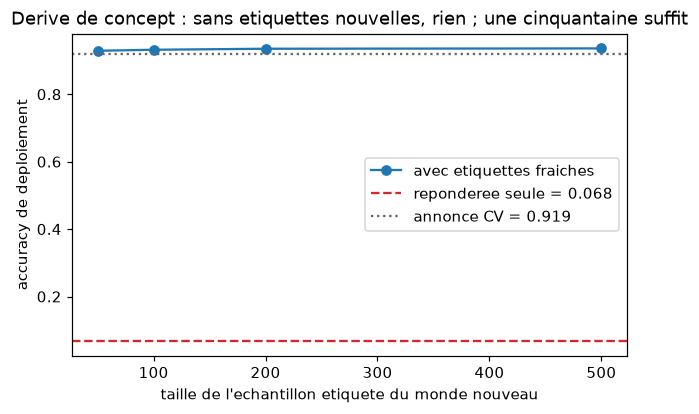

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
table_frais = pd.DataFrame(resultats).set_index("etiquettes fraiches")
ax.plot(table_frais.index, table_frais["accuracy deploiement"], "o-", label="avec etiquettes fraiches")
ax.axhline(avec, ls="--", c="tab:red", label=f"reponderee seule = {avec:.3f}")
ax.axhline(cv_annonce, ls=":", c="0.4", label=f"annonce CV = {cv_annonce:.3f}")
ax.set_xlabel("taille de l'echantillon etiquete du monde nouveau")
ax.set_ylabel("accuracy de deploiement")
ax.set_title("Derive de concept : sans etiquettes nouvelles, rien ; une cinquantaine suffit")
ax.legend()
plt.show()


***
## 5. Exercices

### Exercice 1 — Le détecteur aveugle
Construisez une dérive de covariable qui traverse *une seule* des deux caractéristiques, de faible amplitude. Quel détecteur la voit (KS par caractéristique ? MMD ? classifieur ?) et lequel reste aveugle ? Expliquez pourquoi.


In [15]:
# Exercice 1 -- a completer
# Indice : modifiez UNE seule composante de mu_dep, de +0.3 sigma, et passez les trois detecteurs.
# Etape 1 : construire W_dep_bis
# Etape 2 : lancer KS / classifieur / MMD
# Etape 3 : conclure en une phrase
result = None  # TODO etudiant
print("Exercice a completer")


Exercice a completer


### Exercice 2 — BBSE quand la matrice de confusion est singulière
BBSE inverse la matrice de confusion estimée. Construisez un classifieur volontairement sous-ajusté (pénalité C très forte) pour que cette matrice devienne quasi singulière : que devient l'estimation de `P_dep(y)` ? Que faut-il exiger d'un modèle *avant* de l'utiliser comme instrument de correction ?


In [16]:
# Exercice 2 -- a completer
# Indice : LogisticRegression(C=1e-3) rend le classifieur presque constant.
# Etape 1 : reentrainer avec C tres faible
# Etape 2 : estimer la matrice de confusion et son conditionnement
# Etape 3 : appliquer BBSE et comparer a la vraie P_dep(y)
result = None  # TODO etudiant
print("Exercice a completer")


Exercice a completer


### Exercice 3 — La correction qui échoue (le plus important)
Appliquez la pondération par importance à la dérive de **concept** (les poids sont ceux de la dérive de covariable : `P_dep(x) = P_train(x)`, donc `w(x) = 1` partout... ou presque). Mesurez : combien le score de déploiement remonte-t-il ? Que faut-il de plus pour corriger une dérive de concept — et quel coût métier cela représente-t-il ?


In [17]:
# Exercice 3 -- a completer
# Indice : la derive de concept garde P(x) identique ; les poids d'importance ne voient rien.
# Etape 1 : verifier que w(x) = 1 sur l'echantillon de deploiement
# Etape 2 : reentrainer repondere et mesurer le score
# Etape 3 : conclure -- que manque-t-il, et a quel prix ?
result = None  # TODO etudiant
print("Exercice a completer")


Exercice a completer


***
## 6. Ce qu'il faut retenir

1. **La validation croisée ne teste que le monde d'où elle est tirée.** Son « annonce » est une propriété conjointe du modèle *et* de la distribution d'entraînement — le déploiement rompt le couple. L'écart annonce/produit est la première mesure à instrumenter, avant même de corriger.
2. **Détecter est bon marché** : trois familles (KS par variable, classifieur discriminant, MMD), un simple échantillon *non étiqueté* du déploiement, des verdicts concordants — et la bibliothèque de référence (`alibi-detect`) les implémente toutes.
3. **Deux dérives sur trois se corrigent** : la covariable par pondération d'importance, l'étiquette par BBSE (qui récupère la nouvelle loi `P(y)` depuis les seules prédictions — c'est la pièce la plus rentable du carnet : quelques prédictions non étiquetées redeviennent une estimation de prior).
4. **La dérive de concept n'a pas de correcteur non étiqueté** — ce n'est pas un échec d'ingénierie, c'est une impossibilité informationnelle : `P(x)` ne change pas, aucun signal sur `x` ne peut révéler un changement de `P(y|x)`. La seule voie est un petit échantillon étiqueté du monde nouveau — et la mesure est sans appel : 0,07 → 0,93 dès une cinquantaine d'étiquettes auditées.

Le réflexe du praticien : **mesurer l'écart, détecter non étiqueté, corriger ce qui se corrige, et budgéter l'audit d'étiquettes pour ce qui ne se corrige pas.**


***

## References

1. **Shimodaira, H. (2000).** *Improving predictive inference under covariate shift by minimizing weighted log-likelihood*. Journal of Statistical Planning and Inference, 90(2), 227-244. — La pondération d'importance : minimiser l'espérance sous le monde de déploiement pour corriger un changement de P(x).
2. **Lipton, Z. C., Wang, Y.-X., & Smola, A. (2018).** *Detecting and Correcting for Label Shift with Black Box Predictors*. NeurIPS 2018. — BBSE : la matrice de confusion transporte la distribution des prédictions vers celle des étiquettes, sans une seule étiquette du monde nouveau.
3. **Gretton, A., Borgwardt, K. M., Rasch, M. J., Schölkopf, B., & Smola, A. (2012).** *A Kernel Two-Sample Test*. JMLR, 13, 723-773. — Le MMD : distance maximale de moyennes en espace à noyau, heuristique de la médiane pour la bande passante, test par permutation.
4. **Rabanser, S., Günlük, S., & Wu, Y. (2019).** *Failing Loudly: An Empirical Study of Methods for Detecting Dataset Shift*. NeurIPS 2019. — Le classifieur discriminant comme test à deux échantillons appris, et ce que chaque famille de détecteurs voit ou rate.
5. **Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M., & Bouchachia, A. (2014).** *A Survey on Concept Drift Adaptation*. ACM Computing Surveys, 46(4). — Taxonomie des dérives (virtuelle vs réelle) et des stratégies d'adaptation.
6. **Alibi Detect (Seldon).** Bibliothèque open source de détection d'outliers, d'attaques adverses et de dérive. — Les trois détecteurs SOTA consommés dans ce carnet (KSDrift, ClassifierDrift, MMDDrift) sont les siens, version 0.13.
